# AUROC of every defense per attack

The paper's detector comparison ranks every defense by 1 mean AUROC over the compared models, and a single mean hides which attacks each defense handles. This notebook breaks the same comparison out by attack. It reads the same population `scripts/paper/tab_detectors.py` builds its tables from, the clearing models that carry a reading from every defense, and averages each defense's AUROC over the models of each attack. PSBD-TM and PSBD-RD are read at the adaptive rate rule and the headline quantile, the same rule and quantile the competitor records under `results/<folder>/detectors/` were scored at. It reads cached JSON only and runs in a few seconds.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

from defenses.decision import (
    HEADLINE_QUANTILE,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from scripts.paper._common import (
    HEADLINE_KEY,
    attack_label,
    clearing_cells,
    dataset_label,
    load_coverage,
)
from scripts.paper._style import TEXT_WIDTH
from scripts.paper.tab_detectors import RULE, cell_readings, columns, fully_covered

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

## The compared models

A column mean over whichever models that column happens to cover would make the columns incomparable, so the generator keeps only the clearing models every defense scored. The same filter runs here, through the generator's own `fully_covered`.

In [4]:
coverage = load_coverage("results")
clearing = clearing_cells(coverage)
compared = fully_covered("results", clearing)

print(
    f"{len(compared)} of {len(clearing)} clearing models carry a reading from every defense"
)
print(f"PSBD-TM is {RECOMMENDED_PLACEMENT}, PSBD-RD is {PUBLISHED_PLACEMENT}")
print(
    f"rate rule {RULE}, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile"
)

69 of 71 clearing models carry a reading from every defense
PSBD-TM is before_attention_norm_token_mask, PSBD-RD is post_residual
rate rule adaptive, threshold at the 25% clean-validation quantile


In [5]:
# The paper's column headers carry TeX marks for the 2 registered variants, which
# read poorly in a data frame, so the notebook spells them out.
defenses = columns()
plain_names = {
    name: name.replace("$^\\dagger$", " data limited").replace(
        "$^\\ast$", " calibrated"
    )
    for name in defenses
}

model_rows = []
for cell in compared:
    readings = cell_readings("results", cell, HEADLINE_KEY, "auroc")
    model_rows.append(
        {
            "attack": attack_label(cell["attack"]),
            "dataset": dataset_label(cell["dataset"]),
            **readings,
        }
    )
per_model = pd.DataFrame(model_rows).rename(columns=plain_names)
defense_names = [plain_names[name] for name in defenses]

per_attack = per_model.groupby("attack")[defense_names].mean()  # (attacks, defenses)
models_per_attack = per_model.groupby("attack").size()
per_attack = per_attack.sort_values("PSBD-TM", ascending=False)
assert per_attack.shape == (per_model["attack"].nunique(), len(defense_names))
per_attack.round(3)

,PSBD-TM,PSBD-RD,Conf,STRIP,Scale-Up,Scale-Up data limited,IBD-PSC,IBD-PSC calibrated,TeCo,CD-L,Beatrix,TED,SentiNet
attack,,,,,,,,,,,,,
BadNets,0.992,0.712,0.742,0.968,0.968,0.949,0.768,0.967,0.976,0.943,0.916,0.909,0.499
LF,0.980,0.974,0.642,0.813,0.734,0.677,0.649,0.919,0.477,0.599,0.897,0.858,0.387
Blend,0.966,0.940,0.790,0.916,0.814,0.751,0.894,0.987,0.879,0.821,0.931,0.907,0.431
BPP,0.948,0.945,0.637,0.859,0.399,0.243,0.642,0.920,0.562,0.921,0.926,0.891,0.469
TaCT,0.853,0.470,0.844,0.703,0.805,0.727,0.837,0.876,0.789,0.650,0.743,0.697,0.294
WaNet,0.845,0.956,0.579,0.519,0.615,0.363,0.641,0.749,0.901,0.703,0.570,0.807,0.348
SIG,0.610,0.708,0.519,0.633,0.782,0.689,0.450,0.736,0.625,0.475,0.956,0.777,0.457


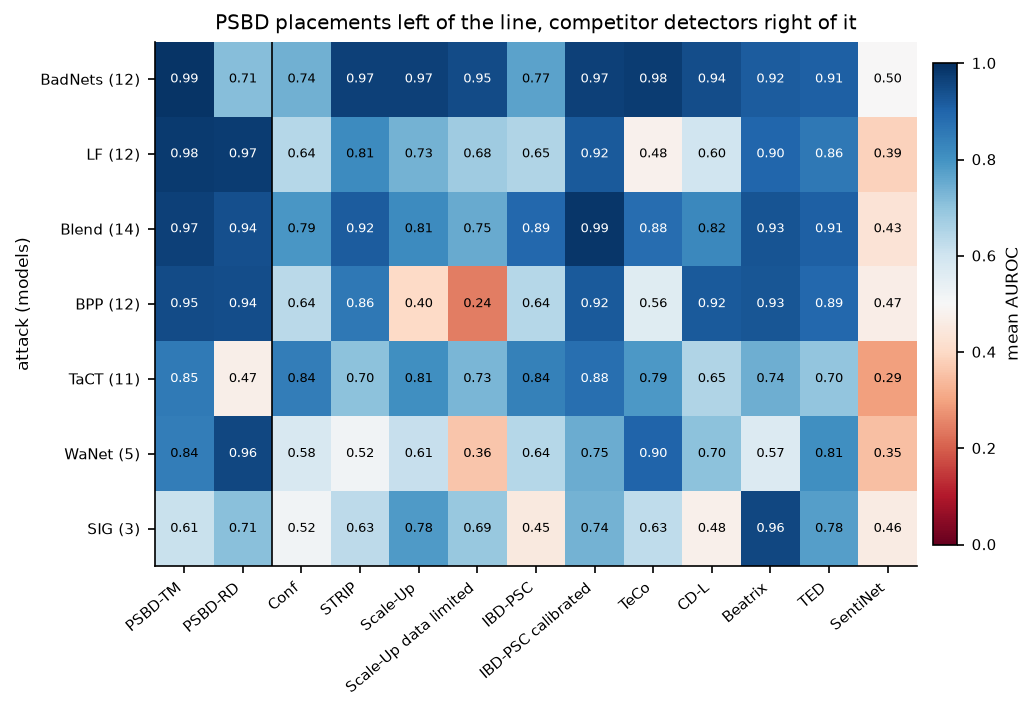

In [6]:
auroc_grid = per_attack.to_numpy()  # (attacks, defenses)
figure, axis = plt.subplots(figsize=(TEXT_WIDTH, 0.42 * len(per_attack) + 1.6))

# Chance sits at the middle of the color scale, so a defense that orders poisoned
# and clean inputs the wrong way round reads red rather than as a pale blue.
color_norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)
image = axis.imshow(auroc_grid, cmap="RdBu", norm=color_norm, aspect="auto")

for row_index in range(auroc_grid.shape[0]):
    for column_index in range(auroc_grid.shape[1]):
        value = auroc_grid[row_index, column_index]
        text_color = "white" if abs(value - 0.5) > 0.35 else "black"
        axis.text(
            column_index,
            row_index,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=6,
            color=text_color,
        )

row_labels = [f"{attack} ({models_per_attack[attack]})" for attack in per_attack.index]
axis.set_xticks(
    range(len(defense_names)), labels=defense_names, rotation=40, ha="right"
)
axis.set_yticks(range(len(row_labels)), labels=row_labels)
axis.grid(False)
axis.axvline(1.5, color="black", linewidth=0.8)
axis.set_ylabel("attack (models)")
figure.colorbar(image, ax=axis, label="mean AUROC", fraction=0.03, pad=0.02)
axis.set_title("PSBD placements left of the line, competitor detectors right of it")
plt.show()

## Leaders per attack

The table below reads the heatmap row by row: which defense has the highest mean on each attack and where the 2 PSBD placements rank among all of them.

In [7]:
ranks = per_attack.rank(axis=1, ascending=False, method="min")  # (attacks, defenses)
leaders = pd.DataFrame(
    {
        "models": models_per_attack.loc[per_attack.index],
        "PSBD-TM": per_attack["PSBD-TM"].round(3),
        "PSBD-TM rank": ranks["PSBD-TM"].astype(int),
        "PSBD-RD": per_attack["PSBD-RD"].round(3),
        "PSBD-RD rank": ranks["PSBD-RD"].astype(int),
        "leader": per_attack.idxmax(axis=1),
        "leader AUROC": per_attack.max(axis=1).round(3),
    }
)
tm_leads = (ranks["PSBD-TM"] == 1).sum()
tm_beats_rd = (per_attack["PSBD-TM"] > per_attack["PSBD-RD"]).sum()
print(f"PSBD-TM leads {tm_leads} of {len(per_attack)} attacks")
print(f"PSBD-TM beats PSBD-RD on {tm_beats_rd} of {len(per_attack)} attacks")
leaders

PSBD-TM leads 3 of 7 attacks
PSBD-TM beats PSBD-RD on 5 of 7 attacks


,models,PSBD-TM,PSBD-TM rank,PSBD-RD,PSBD-RD rank,leader,leader AUROC
attack,,,,,,,
BadNets,12,0.992,1,0.712,12,PSBD-TM,0.992
LF,12,0.980,1,0.974,2,PSBD-TM,0.980
Blend,14,0.966,2,0.940,3,IBD-PSC calibrated,0.987
BPP,12,0.948,1,0.945,2,PSBD-TM,0.948
TaCT,11,0.853,2,0.470,12,IBD-PSC calibrated,0.876
WaNet,5,0.845,3,0.956,1,PSBD-RD,0.956
SIG,3,0.610,9,0.708,5,Beatrix,0.956


## Reading the heatmap

No single defense leads every row. PSBD-TM leads on BadNets, LF and BPP and ranks second on Blend and TaCT, and its largest gains over PSBD-RD are on BadNets and TaCT, where PSBD-RD falls below chance on TaCT. The calibrated IBD-PSC port leads Blend and TaCT and sits near the top of every row, which is the tie the paper reports. WaNet is the attack where PSBD-RD beats PSBD-TM by a clear margin, and SIG, led by Beatrix, rests on too few models for its row to carry weight. SentiNet reads at or below chance on every attack. Each row is a mean over models of different datasets and poison rates, and the models per attack are uneven, so a row compares defenses with each other and says little about how hard 1 attack is against another. The overall means in `paper/tables/detectors_auroc.tex` weigh every model equally rather than every attack, which is why they read as a near tie with IBD-PSC while this breakdown shows where each of the 2 wins.